# Discovery cohort monocytes analysis

In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(future)
  library(tidyverse)
  library(ggforce)
  library(patchwork)
  library(cowplot)
  library(ComplexHeatmap)
})

In [2]:
options(future.globals.maxSize = 1000000 * 1024^2, hpc.ncpus = 16)
plan(multicore, workers = getOption("hpc.ncpus", 1))

# Helper functions

In [3]:
source("../scripts/plotting.R")

# Load data

### Filtered dataset

QS object generated by running notebooks in `03_annotate`

In [ ]:
seu <- qs::qread(file = "../data/processed/cite_seq/cohort_treatment_naive/annotated/annotated.qs", nthreads = getOption("hpc.ncpus", 1))

### totalVI denoised RNA and ADT data

In [ ]:
rna.denoised <- h5ad.to.seurat(
  file = "../data/processed/cite_seq/cohort_treatment_naive/models/totalvi/totalvi_rna_denoised.h5ad",
  x = "data",
  raw = NULL,
  assay.name = "RNA_denoised"
)

In [ ]:
adt.denoised <- h5ad.to.seurat(
  file = "../data/processed/cite_seq/cohort_treatment_naive/models/totalvi/totalvi_adt_denoised.h5ad",
  x = "data",
  raw = NULL,
  assay.name = "ADT_denoised"
)

In [7]:
seu[["RNA_denoised"]] <- rna.denoised[["RNA_denoised"]]
seu[["ADT_denoised"]] <- adt.denoised[["ADT_denoised"]]

In [8]:
seu

An object of class Seurat 
31865 features across 264512 samples within 5 assays 
Active assay: RNA (26424 features, 4993 variable features)
 3 layers present: data, counts, scale.data
 4 other assays present: ADT, ADTC, RNA_denoised, ADT_denoised
 5 dimensional reductions calculated: pca, integrated.rna, apca, integrated.adt, umap

### Perturbation scores

In [ ]:
meld.stats <- set_names(c("Early", "Late")) %>%
  map(
    .f = function(x) {
      read.table(
        file = glue::glue("../results/tables/cite_seq/cohort_treatment_naive/meld_stats_{x}.tsv"),
        sep = "\t",
        header = TRUE
      )
    }
  )

### Program scores

In [ ]:
gep.usage <- set_names(c("B", "DC", "Mono", "NK", "T")) %>%
  map(
    .f = function(x) {
      mat <- read_tsv(
        file = glue::glue("../results/tables/cite_seq/cohort_treatment_naive/gep/{x}/finalised/usage.tsv"),
        col_names = TRUE,
        show_col_types = FALSE
      ) %>%
        column_to_rownames("...1") %>%
        as.matrix()
      labels <- yaml::read_yaml(glue::glue("../results/tables/cite_seq/cohort_treatment_naive/gep/{x}/finalised/module_labels.yaml"))
      colnames(mat) <- labels[colnames(mat)]
      return(t(mat))
    }
  )

New names:
* `` -> `...1`
New names:
* `` -> `...1`
New names:
* `` -> `...1`
New names:
* `` -> `...1`
New names:
* `` -> `...1`


# Compute UMAP

In [ ]:
seu <- RunUMAP(
  seu,
  reduction = "integrated.rna",
  dims = 1:50,
  metric = "cosine",
  n.neighbors = 30L,
  min.dist = 0.3,
  spread = 1,
  n.epochs = 200L,
  return.model = TRUE
)

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"
UMAP will return its model

18:11:23 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

18:11:23 Read 264512 rows and found 50 numeric columns

18:11:23 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

18:11:23 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:12

# Donor metadata

In [ ]:
donor.metadata <- read.table(
  file = "../data/metadata/donor_metadata.tsv",
  header = TRUE,
  sep = "\t",
  stringsAsFactors = FALSE
) %>%
  mutate(
    sex = factor(sex, levels = c("F", "M")),
    disease_type = factor(disease_type, levels = c("RR_high", "RR_low", "PP")),
    infusion_1_date = ymd(infusion_1_date)
  )

In [ ]:
donor.metadata

donor_id,age,sex,bmi,disease_type,disease_duration,relapses_last_2_yr,relapses_last_yr,last_relapse_interval,mri_baseline_activity,relapses_on_ocrelizumab,mri_on_ocrelizumab_activity,edss_edmus,treatment_naive,prior_dmt,infusion_1_date,infusion_2_interval,infusion_3_interval,infusion_4_interval,infusion_5_interval
<chr>,<int>,<fct>,<dbl>,<fct>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<lgl>,<lgl>,<date>,<int>,<int>,<int>,<int>
OCRZ003,19,M,26.61,RR_high,0,4,4,4,new,0,none,1.0,TRUE,NA,2019-06-26,14,189,303,263
OCRZ004,24,F,22.48,RR_high,1,2,2,1,new,0,none,1.5,TRUE,NA,2019-07-10,14,226,259,252
OCRZ011,39,M,23.71,RR_low,0,1,1,4,enhancing,0,none,1.0,TRUE,NA,2019-09-11,14,405,483,427
OCRZ012,46,F,32.66,RR_high,1,6,2,9,none,0,none,6.0,TRUE,NA,2019-09-18,14,156,287,270
OCRZ013,44,F,26.78,RR_high,0,3,2,4,none,0,none,5.0,TRUE,NA,2019-10-02,14,307,343,322
OCRZ014,47,F,25.48,RR_high,1,4,3,8,enhancing,0,none,5.0,TRUE,NA,2019-11-06,14,328,290,270
OCRZ019,61,F,28.83,PP,2,0,0,NA,enhancing,0,none,6.0,TRUE,NA,2020-01-14,15,202,287,409
OCRZ020,24,F,23.83,RR_low,1,2,1,12,none,0,none,3.0,TRUE,NA,2020-01-07,14,308,385,280
OCRZ022,60,M,24.81,PP,3,0,0,NA,new,0,none,6.0,TRUE,NA,2020-01-29,14,202,231,245


# Custom colour palettes

In [7]:
cluster.main.pal <- c(
  B = pals::brewer.reds(100)[90],
  DC = pals::brewer.greys(100)[90],
  Mono = pals::brewer.purples(100)[90],
  ILC = pals::brewer.oranges(100)[50],
  NK = pals::brewer.blues(100)[90],
  T = pals::brewer.greens(100)[90]
)

In [8]:
cluster.coarse.pal <- c(
  B_naive = pals::brewer.reds(5)[3],
  B_memory = pals::brewer.reds(5)[2],
  B_plasma = pals::brewer.reds(5)[4],
  DC_AXL_SIGLEC6 = pals::brewer.greys(5)[3],
  DC_conventional = pals::brewer.greys(5)[2],
  DC_plasmacytoid = pals::brewer.greys(5)[4],
  ILC = pals::brewer.oranges(100)[50],
  Mono_CD14 = pals::brewer.purples(5)[2],
  Mono_CD16 = pals::brewer.purples(5)[4],
  NK_CD56dim = pals::brewer.blues(5)[4],
  NK_CD56bright = pals::brewer.blues(5)[2],
  T_CD4_naive = pals::brewer.greens(10)[2],
  T_CD4_memory = pals::brewer.greens(10)[7],
  T_regulatory_naive = pals::brewer.greens(10)[5],
  T_regulatory_memory = pals::brewer.greens(10)[9],
  T_CD8_naive = pals::brewer.greens(10)[10],
  T_CD8_memory = pals::brewer.greens(10)[6],
  T_MAIT = pals::brewer.greens(10)[4],
  T_GD = pals::brewer.greens(10)[8],
  T_DN = pals::brewer.greens(10)[3]
)

In [9]:
cluster.pal <- c(cluster.main.pal, cluster.coarse.pal)

# Visualise monocytes

Inferred data type as 'discrete'. To override, set type explicitly.



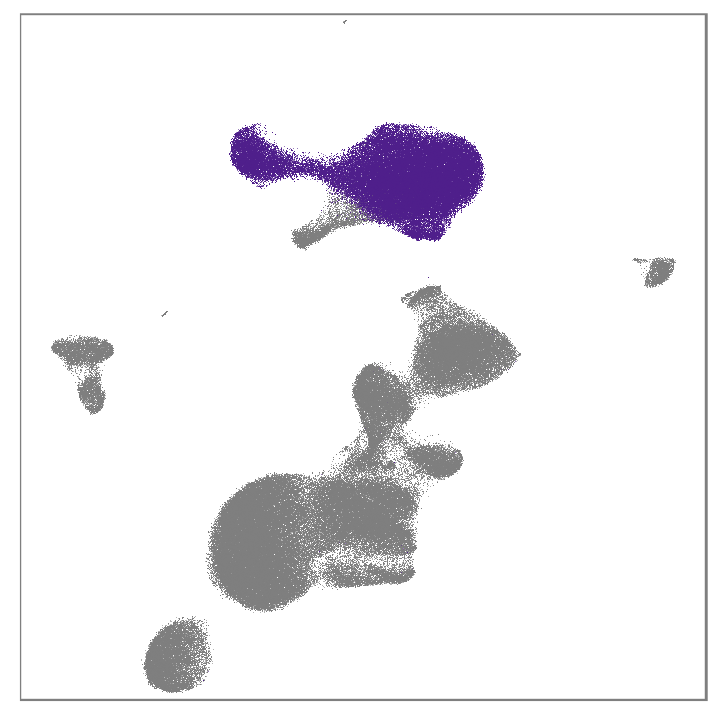

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(seu, vars = c("umap_1", "umap_2", "cluster_main")) %>%
  mutate(
    cluster_main = if_else(cluster_main == "Mono", "Mono", NA_character_)
  )

plot <- embedding.plot(data, colour = "cluster_main", cmap = cluster.pal, show.legend = FALSE, rasterise = TRUE, size.adj = 2, alpha = 1, pixels = c(2048, 2048)) +
  scale_y_continuous(expand = c(0.01, 0.01)) +
  theme(
    axis.title = element_blank(),
    panel.border = element_rect(colour = "grey50")
  )

plot

ggsave(
  plot = plot,
  filename = "../results/plots/cohort_treatment_naive_mono_cell_type_umap_global.pdf",
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Subset to monocytes

In [ ]:
# Subset to monocytes only
sub <- subset(seu, subset = cluster_main == "Mono")
Idents(sub) <- "cluster_fine"

In [ ]:
sub[["GEP"]] <- CreateAssayObject(data = gep.usage[["Mono"]])

Warning message:
"Layer counts isn't present in the assay object; returning NULL"


# Recompute UMAP projection

In [20]:
sub <- sub %>%
  RunUMAP(
    reduction = "integrated.rna",
    dims = 1:50,
    metric = "cosine",
    n.neighbors = 30L,
    min.dist = 0.3,
    spread = 1,
    n.epochs = 200L
  )

14:45:08 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

14:45:08 Read 7496 rows and found 50 numeric columns

14:45:08 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

14:45:08 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%



[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

14:45:09 Writing NN index file to temp file /tmp/RtmpDiQTfm/file1f527261eba598

14:45:09 Searching Annoy index using 16 threads, search_k = 3000

14:45:09 Annoy recall = 100%

14:45:12 Commencing smooth kNN distance calibration using 16 threads
 with target n_neighbors = 30

14:45:13 Initializing from normalized Laplacian + noise (using RSpectra)

14:45:13 Commencing optimization for 200 epochs, with 328222 positive edges

14:45:17 Optimization finished



# Visualise cell types

Inferred data type as 'discrete'. To override, set type explicitly.



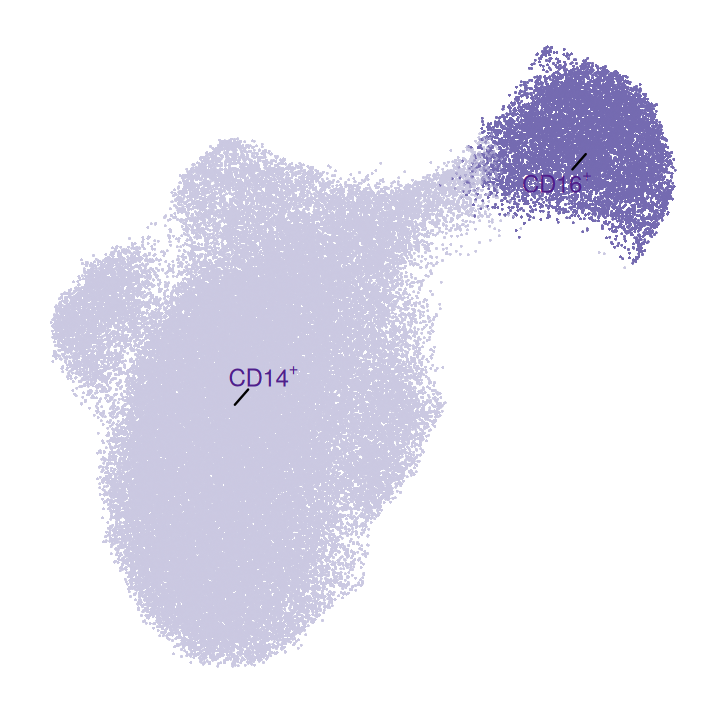

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(sub, vars = c("umap_1", "umap_2", "cluster_coarse", "cluster_main"))
labels <- data %>%
  group_by(cluster_coarse) %>%
  summarise(cluster_main = first(cluster_main)) %>%
  left_join(calculate.centroid.density(data, group.var = "cluster_coarse", x.var = "umap_1", y.var = "umap_2"), by = "cluster_coarse") %>%
  mutate(
    cluster_coarse = case_match(
      cluster_coarse,
      "Mono_CD14" ~ "CD14^'+'",
      "Mono_CD16" ~ "CD16^'+'"
    )
  )

plot <- embedding.plot(data, colour = "cluster_coarse", cmap = cluster.pal, show.legend = FALSE, rasterise = TRUE, size.adj = 5, alpha = 1, pixels = c(2048, 2048)) +
  ggrepel::geom_text_repel(
    data = labels,
    mapping = aes(x = x, y = y, colour = cluster_main, label = cluster_coarse),
    segment.colour = "black",
    box.padding = 0.75,
    size = 5,
    max.overlaps = Inf,
    min.segment.length = 0,
    seed = 42,
    parse = TRUE,
    show.legend = FALSE
  ) +
  scale_y_continuous(expand = c(0.05, 0.05)) +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank()
  )

plot

ggsave(
  plot = plot,
  filename = "../results/plots/cohort_treatment_naive_mono_cell_type_umap.pdf",
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Visualise perturbation effects of treatment

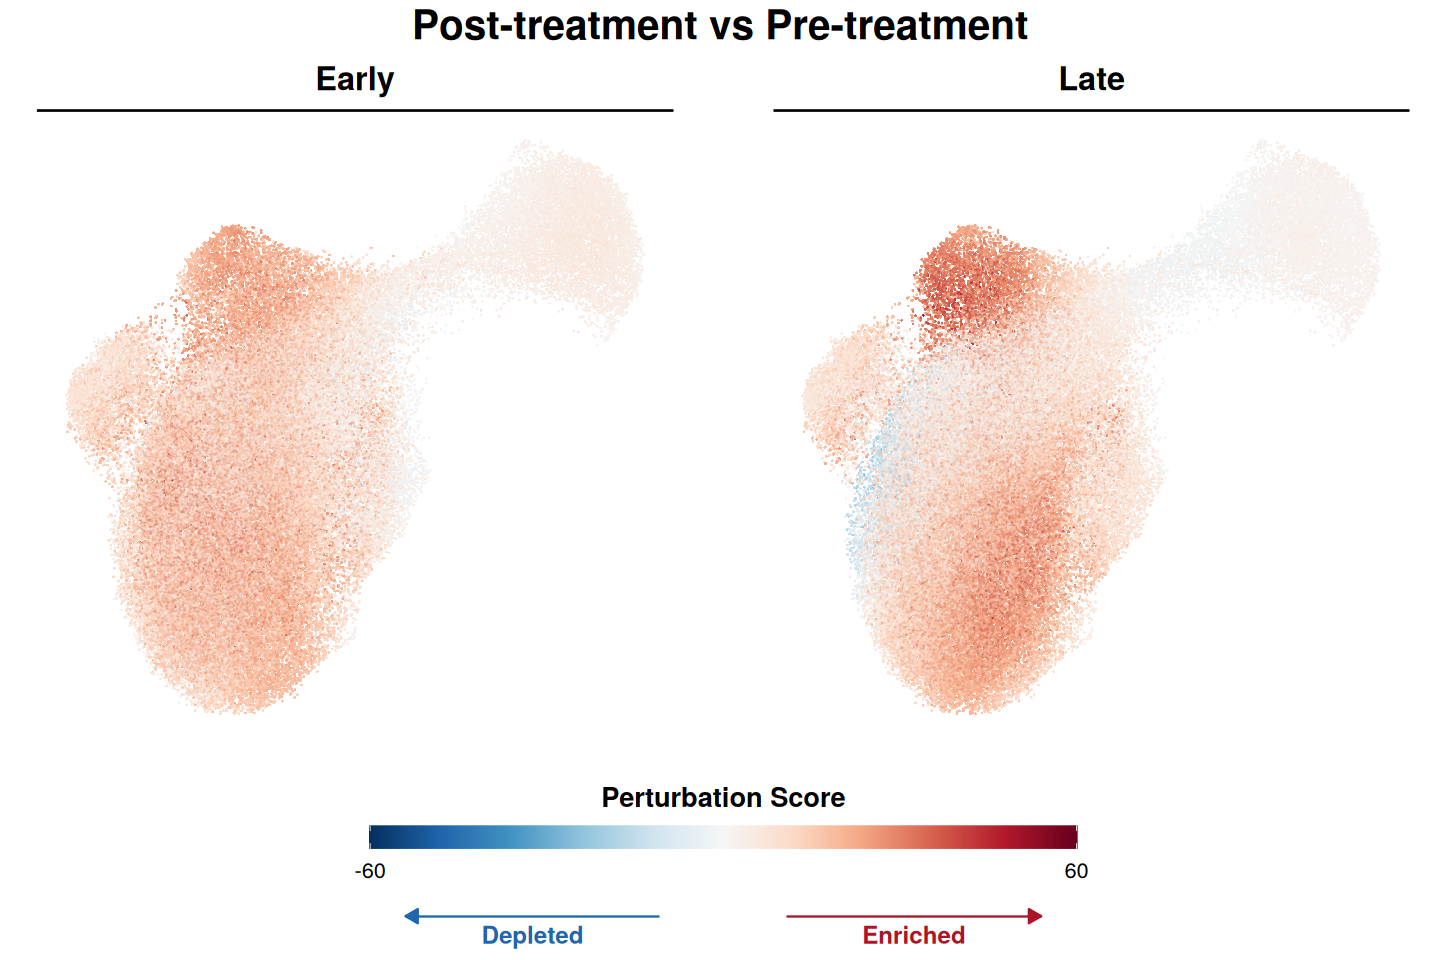

In [ ]:
options(repr.plot.width = 12, repr.plot.height = 8)

cond <- c("Early", "Late")
plots <- set_names(cond) %>%
  map(
    .f = function(x, data, stats) {
      data <- data %>%
        bind_cols(stats[[x]][rownames(data), ])
      p <- embedding.plot(
        data,
        colour = "z",
        cmap = rev(pals::brewer.rdbu(100)),
        type = "diverging",
        limits = c(-60, 60),
        breaks = c(-60, 60),
        labs = list(title = x, colour = "Perturbation Score"),
        verbose = FALSE,
        rasterise = TRUE,
        size.adj = 5,
        alpha = 1,
        pixels = c(2048, 2048)
      ) +
        scale_y_continuous(expand = c(0.05, 0.05)) +
        annotate(
          "segment",
          x = -Inf, xend = Inf,
          y = Inf, yend = Inf,
          colour = "black",
          size = 1,
          linetype = 1
        ) +
        theme(
          panel.border = element_blank(),
          axis.title = element_blank(),
          plot.title = element_text(face = "bold", hjust = 0.5),
          legend.position = "none",
          plot.margin = margin(5, 5, 5, 5, "pt")
        )

      p <- ggrastr::rasterise(p, layers = "Points", dpi = 600)

      return(p)
    },
    data = FetchData(sub, vars = c("umap_1", "umap_2")),
    stats = meld.stats
  )

annotation.arrow <- ggplot() +
  geom_segment(aes(x = 0.45, xend = 0.25, y = 0.7, yend = 0.7),
    arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
    linewidth = 0.5, color = pals::brewer.rdbu(100)[90]
  ) +
  geom_segment(aes(x = 0.55, xend = 0.75, y = 0.7, yend = 0.7),
    arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
    linewidth = 0.5, color = pals::brewer.rdbu(100)[10]
  ) +
  geom_text(aes(x = 0.35, y = 0.3, label = "Depleted"),
    hjust = 0.5, size = 5, color = pals::brewer.rdbu(100)[90], fontface = "bold"
  ) +
  geom_text(aes(x = 0.65, y = 0.3, label = "Enriched"),
    hjust = 0.5, size = 5, color = pals::brewer.rdbu(100)[10], fontface = "bold"
  ) +
  xlim(0, 1) +
  ylim(0, 1) +
  theme_void()

plot.combined <- (plots[["Early"]] | plot_spacer() | plots[["Late"]]) +
  plot_layout(widths = c(1, 0.05, 1), guides = "collect") &
  theme(
    legend.position = "bottom",
    legend.title.position = "top",
    legend.direction = "horizontal",
    legend.title = element_text(vjust = 1, face = "bold", hjust = 0.5),
    legend.key.width = unit(3, "cm"),
    legend.key.height = unit(0.5, "cm"),
    legend.margin = margin(t = 10, b = 5)
  )

final.plot <- plot.combined / annotation.arrow +
  plot_layout(heights = c(10, 0.8)) +
  plot_annotation(
    title = "Post-treatment vs Pre-treatment",
    theme = theme(
      plot.title = element_text(size = 24, face = "bold", hjust = 0.5)
    )
  )

final.plot

ggsave(
  plot = final.plot,
  filename = "../results/plots/cohort_treatment_naive_mono_perturbation_scores_umap.pdf",
  width = 12,
  height = 8,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Program effect scores

In [ ]:
shap <- read.table(
  file = "../results/tables/cite_seq/cohort_treatment_naive/shap/Mono/Late.tsv",
  sep = "\t",
  header = TRUE,
  row.names = 1,
  check.names = FALSE
)

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead."


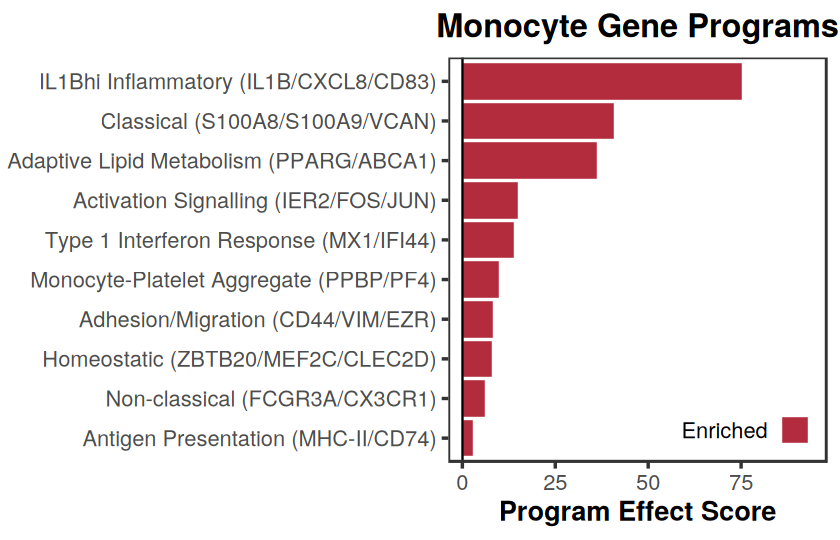

In [ ]:
options(repr.plot.width = 7, repr.plot.height = 4.5)

data <- map_dfr(
  .x = grep(pattern = "Housekeeping|Contamination|Artefactual", x = colnames(shap), value = TRUE, invert = TRUE),
  .f = function(x,
                shap.df = shap,
                gep.df = as.data.frame(t(gep.usage[["Mono"]])),
                perturbation.scores = meld.stats[["Late"]][rownames(shap), "z", drop = TRUE],
                threshold = 0.2) {
    usage <- gep.df[[x]]
    shap.values <- shap.df[[x]]
    idx <- which(usage > threshold)
    mean.abs.shap <- mean(abs(shap.values[idx]))
    mean.perturbation <- mean(perturbation.scores[idx])
    return(list(
      program = x,
      mean_abs_shap = mean.abs.shap,
      mean_perturbation = mean.perturbation,
      program_effect_score = mean.abs.shap * mean.perturbation
    ))
  }
) %>%
  mutate(effect_direction = case_when(
    mean_perturbation > 0 ~ "Enriched",
    mean_perturbation < 0 ~ "Depleted",
    TRUE ~ "No change"
  ))

plot <- ggplot(data = data, mapping = aes(x = program_effect_score, y = reorder(program, program_effect_score), fill = effect_direction)) +
  geom_col(width = 0.95, color = "white", size = 0.3, alpha = 0.9) +
  labs(
    title = "Monocyte Gene Programs",
    x = "Program Effect Score",
    y = NULL,
    fill = NULL
  ) +
  scale_x_continuous(expand = expansion(mult = c(0.05, 0.3))) +
  geom_vline(xintercept = 0, color = "black") +
  scale_fill_manual(
    values = c(
      "Depleted" = pals::brewer.rdbu(100)[90],
      "No change" = pals::brewer.rdbu(100)[50],
      "Enriched" = pals::brewer.rdbu(100)[10]
    ),
    breaks = c("Enriched", "Depleted")
  ) +
  theme_custom() +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold"),
    legend.position = "top",
    legend.title = element_text(face = "bold")
  ) +
  inset.legend(location = "bottomright")

plot

ggsave(
  plot = plot,
  filename = "../results/plots/cohort_treatment_naive_mono_program_effect_scores_bar.pdf",
  width = 7,
  height = 4.5,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Classical-Inflammatory gene signature

In [ ]:
chosen.gep <- Features(sub[["GEP"]])[c(1, 7, 8)]
chosen.gep

[1] "Classical (S100A8/S100A9/VCAN)"         
[2] "Adaptive Lipid Metabolism (PPARG/ABCA1)"
[3] "IL1Bhi Inflammatory (IL1B/CXCL8/CD83)"

In [ ]:
sub$program_score <- apply(GetAssayData(sub, assay = "GEP", layer = "data")[chosen.gep, ], 2, sum)

# Donor-level program score comparisons

In [ ]:
plots <- list()

In [ ]:
data <- FetchData(sub, vars = c("donor", "condition", "cluster_coarse", "program_score")) %>%
  left_join(donor.metadata, by = join_by(donor == donor_id)) %>% 
  filter(cluster_coarse == "Mono_CD14")

data.summary <- data %>%
  group_by(disease_type, donor, condition) %>%
  summarise(
    program_score = mean(program_score, na.rm = TRUE),
    age = first(age),
    sex = first(sex),
    .groups = "drop"
  )

In [ ]:
model <- lmerTest::lmer(
  program_score ~ disease_type * condition + age + sex + (1 | donor),
  data = data.summary
)

In [ ]:
emm <- emmeans::emmeans(model, ~ disease_type * condition, lmer.df = "Satterthwaite")

contrasts <- list(
  "Early vs Baseline" = c(-1, -1, -1, 1, 1, 1, 0, 0, 0),
  "Late vs Baseline"  = c(-1, -1, -1, 0, 0, 0, 1, 1, 1),
  "Late vs Early"     = c(0, 0, 0, -1, -1, -1, 1, 1, 1)
)

stats <- emmeans::contrast(emm, method = contrasts, adjust = "none") %>%
  summary(infer = TRUE) %>%
  mutate(
    p.adj = p.adjust(p.value, method = "BH"),
    significance = case_when(
      p.adj < 0.001 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n***"),
      p.adj < 0.01 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n**"),
      p.adj < 0.05 ~ glue::glue("p = {round(p.adj, 3)}\n*"),
      p.adj < 0.1 ~ glue::glue("p = {round(p.adj, 3)}\n."),
      TRUE ~ glue::glue("p = {round(p.adj, 3)}\nns")
    )
  ) %>%
  rowwise() %>%
  mutate(
    group1 = str_trim(str_split_i(contrast, " vs ", 1)),
    group2 = str_trim(str_split_i(contrast, " vs ", 2))
  ) %>%
  ungroup() %>%
  mutate(
    y.position = c(0.7, 0.775, 0.7)
  )

In [ ]:
stats

contrast,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value,p.adj,significance,group1,group2,y.position
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<glue>,<chr>,<chr>,<dbl>
Early vs Baseline,0.151251339,0.08595291,22,-0.02700408,0.3295068,1.75970010,0.09235882,0.1578550,p = 0.158 ns,Early,Baseline,0.700
Late vs Baseline,0.145222186,0.08595291,22,-0.03303323,0.3234776,1.68955525,0.10523668,0.1578550,p = 0.158 ns,Late,Baseline,0.775
Late vs Early,-0.006029153,0.08595291,22,-0.18428457,0.1722263,-0.07014484,0.94471209,0.9447121,p = 0.945 ns,Late,Early,0.700


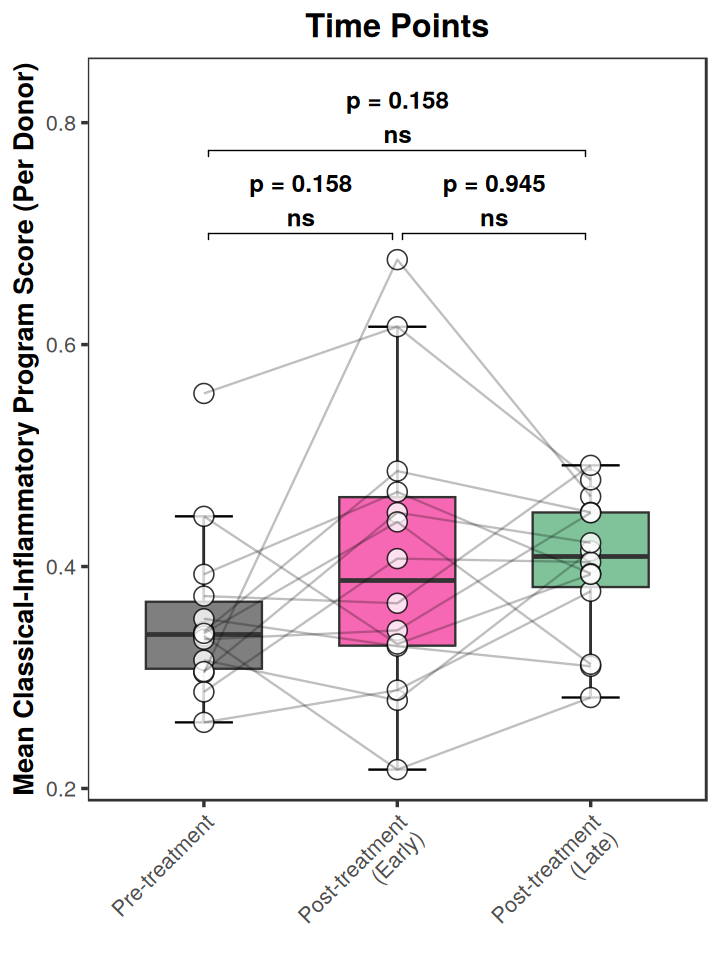

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 8)

plots[[1]] <- ggplot(data = data.summary, mapping = aes(x = condition, y = program_score)) +
  stat_boxplot(
    geom = "errorbar",
    width = 0.3
  ) +
  geom_boxplot(
    mapping = aes(fill = condition),
    width = 0.6,
    outlier.shape = NA,
    alpha = 1,
    size = 0.5
  ) +
  geom_point(
    data = data.summary,
    size = 5,
    alpha = 0.8,
    stroke = 0.5,
    shape = 21,
    fill = "white",
    color = "black"
  ) +
  geom_line(
    data = data.summary,
    mapping = aes(group = donor),
    color = "black",
    alpha = 0.25,
    linewidth = 0.5
  ) +
  ggpubr::stat_pvalue_manual(
    data = stats,
    label = "significance",
    fontface = "bold",
    size = 5,
    tip.length = 0.01,
    bracket.shorten = -0.05
  ) +
  scale_x_discrete(labels = c("Baseline" = "Pre-treatment", "Early" = "Post-treatment\n(Early)", "Late" = "Post-treatment\n(Late)")) +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) +
  scale_fill_manual(values = c("grey50", pals::brewer.qualseq(8)[c(6, 4)])) +
  labs(
    title = "Time Points",
    subtitle = NULL,
    x = NULL,
    y = "Mean Classical-Inflammatory Program Score (Per Donor)"
  ) +
  theme_custom() +
  theme(
    strip.background = element_blank(),
    strip.text = element_text(size = 12, face = "bold", color = "grey20", margin = margin(6, 6, 6, 6)),
    strip.placement = "outside",
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none",
    panel.spacing = unit(5, "mm")
  )

plots[[1]]

In [ ]:
contrasts <- list(
  "RR_low vs RR_high" = c(-1, 1, 0, 0, 0, 0, 0, 0, 0),
  "PP vs RR_high"     = c(-1, 0, 1, 0, 0, 0, 0, 0, 0),
  "PP vs RR_low"      = c(0, -1, 1, 0, 0, 0, 0, 0, 0)
)

stats <- emmeans::contrast(emm, method = contrasts, adjust = "none") %>%
  summary(infer = TRUE) %>%
  mutate(
    p.adj = p.adjust(p.value, method = "BH"),
    significance = case_when(
      p.adj < 0.001 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n***"),
      p.adj < 0.01 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n**"),
      p.adj < 0.05 ~ glue::glue("p = {round(p.adj, 3)}\n*"),
      p.adj < 0.1 ~ glue::glue("p = {round(p.adj, 3)}\n."),
      TRUE ~ glue::glue("p = {round(p.adj, 3)}\nns")
    )
  ) %>%
  rowwise() %>%
  mutate(
    group1 = str_trim(str_split_i(contrast, " vs ", 1)),
    group2 = str_trim(str_split_i(contrast, " vs ", 2))
  ) %>%
  ungroup() %>%
  mutate(
    y.position = c(0.6, 0.65, 0.6)
  )

In [ ]:
stats

contrast,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value,p.adj,significance,group1,group2,y.position
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<glue>,<chr>,<chr>,<dbl>
RR_low vs RR_high,-0.05148551,0.06090624,23.78129,-0.17725103,0.0742800,-0.8453240,0.4063549,0.6095323,p = 0.61 ns,RR_low,RR_high,0.60
PP vs RR_high,0.02307634,0.07873517,15.11875,-0.14462896,0.1907816,0.2930881,0.7734393,0.7734393,p = 0.773 ns,PP,RR_high,0.65
PP vs RR_low,0.07456185,0.07312568,17.80142,-0.07919243,0.2283161,1.0196398,0.3215576,0.6095323,p = 0.61 ns,PP,RR_low,0.60


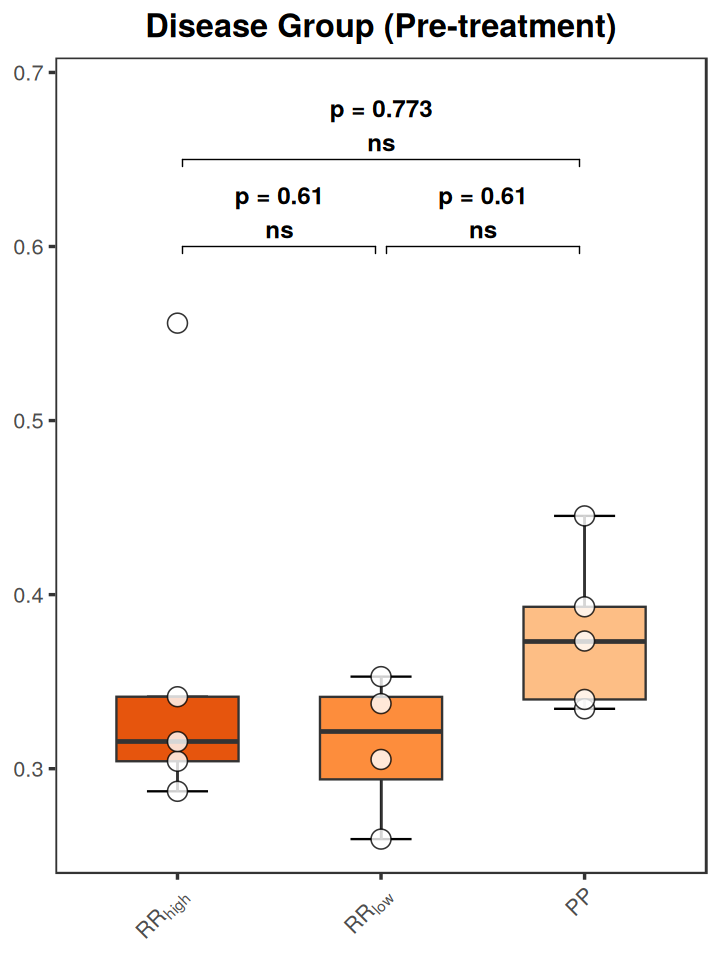

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 8)

plots[[2]] <- ggplot(data = data.summary |> filter(condition == "Baseline"), mapping = aes(x = disease_type, y = program_score)) +
  stat_boxplot(
    geom = "errorbar",
    width = 0.3
  ) +
  geom_boxplot(
    mapping = aes(fill = disease_type),
    width = 0.6,
    outlier.shape = NA,
    alpha = 1,
    size = 0.5
  ) +
  geom_point(
    size = 5,
    alpha = 0.8,
    stroke = 0.5,
    shape = 21,
    fill = "white",
    color = "black"
  ) +
  ggpubr::stat_pvalue_manual(
    data = stats,
    label = "significance",
    fontface = "bold",
    size = 5,
    tip.length = 0.01,
    bracket.shorten = -0.05
  ) +
  scale_x_discrete(
    labels = function(x) {
      case_match(
        x,
        "RR_high" ~ "RR[high]",
        "RR_low" ~ "RR[low]",
        "PP" ~ "PP"
      ) %>%
        parse(text = .)
    }
  ) +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) +
  scale_fill_manual(values = pals::brewer.oranges(5)[4:2] |> setNames(c("RR_high", "RR_low", "PP"))) +
  labs(
    title = "Disease Group (Pre-treatment)",
    subtitle = NULL,
    x = NULL,
    y = NULL
  ) +
  theme_custom() +
  theme(
    strip.background = element_blank(),
    strip.text = element_text(size = 12, face = "bold", color = "grey20", margin = margin(6, 6, 6, 6)),
    strip.placement = "outside",
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none",
    panel.spacing = unit(5, "mm")
  )

plots[[2]]

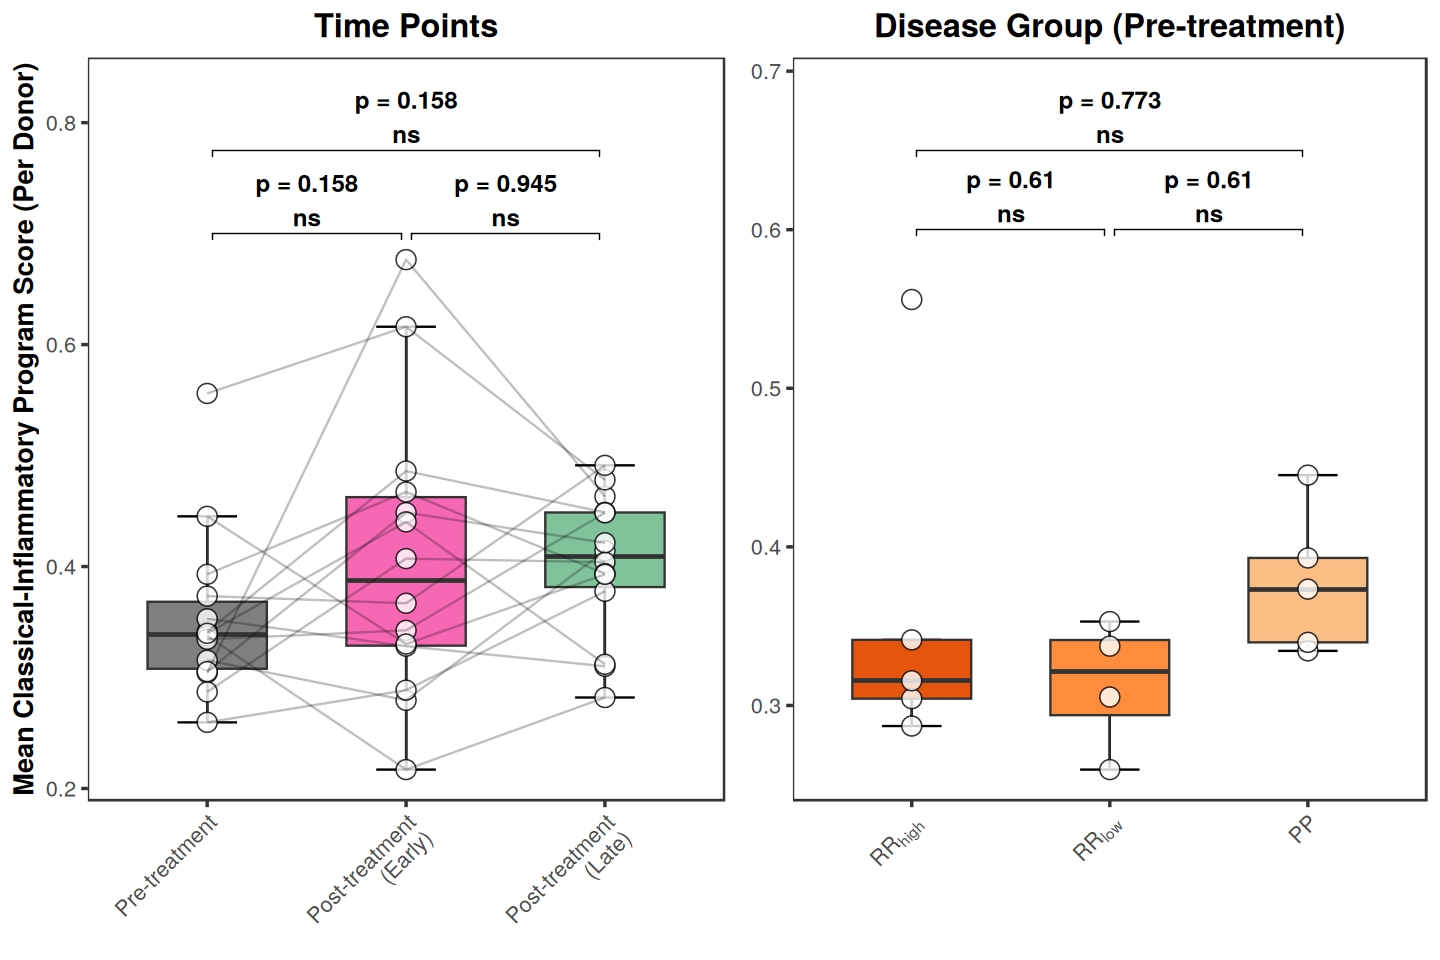

In [ ]:
options(repr.plot.width = 12, repr.plot.height = 8)

plot.combined <- plot_grid(plotlist = plots, nrow = 1, align = "h", rel_widths = c(1.05, 1))

plot.combined

ggsave(
  plot = plot.combined,
  filename = "../results/plots/cohort_treatment_naive_classicalinflammatory_program_score_boxplots.pdf",
  width = 12,
  height = 8,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Session Info

In [8]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /ceph/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
[1] C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] ComplexHeatmap_2.18.0 cowplot_1.1.3         patchwork_1.3.0      
 [4] ggforce_0.4.2         lubridate_1.9.3       forcats_1.0.0        
 [7] stringr_1.5.1         dplyr_1.1.4           purrr_1.0.2          
[10] readr_2.1.5           tidyr_1.3.1           tibble_3.2.1         
[13] ggplot2_3.5.1         tidyverse_2.0.0       future_1.34.0        
[16] Seurat_5.1.0          SeuratObject_5.0.2    sp_2.1-4             

loaded via a namespace (and not attached):
  [1] RcppAnnoy_0.0.22       splines_4.3.3          later_1.3.2         